<a href="https://colab.research.google.com/github/GabrielaCordeiro0/Churn-/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🏦 Contexto da Instituição: "Financeira Mulher Segura"
Somos um banco digital focado em crédito e serviços financeiros para mulheres empreendedoras.

120 mil contas abertas (Usuárias cadastradas).

18 mil clientes ativas/prime (Assinantes que pagam mensalidade de conta VIP ou usam o cartão mensalmente).

Receita Média por Cliente (ARPU): R$ 39/mês (Substitui o ticket médio).

CAC Médio: R$ 52.

LTV Médio: R$ 148.

Churn Mensal (Inatividade > 30 dias): 12%.

#🚨 Problema de Negócio
O churn de 12% indica que estamos perdendo clientes logo após elas utilizarem o primeiro limite de crédito ou o bônus de boas-vindas. O objetivo é reduzir para 8% identificando quem está prestes a abandonar o cartão como sua forma principal de pagamento.

#📌 Sua Missão (como Cientista de Dados)

Você precisa desenvolver um modelo de predição de churn que:



Identifique usuárias com alta probabilidade de cancelar nos próximos 30 dias.

Gere um score de risco.

Permita que o time de marketing atue preventivamente (campanha de retenção).

#Dados - Leitura e Analises Iniciais

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



In [6]:
df = pd.read_csv('/BankChurners.csv')
#  Removendo as duas últimas colunas que costumam vir nesse dataset específico
df = df.iloc[:, :-2]
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [10]:
# Checando se há valores missing
df.isnull().values.any()

np.False_

In [11]:
df.describe()
df['Attrition_Flag'].value_counts(normalize=True)

,proportion
Attrition_Flag,
Existing Customer,0.83934
Attrited Customer,0.16066


#Feature Engineering

In [13]:
#variavel alvo
df['churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

In [16]:
#  Remoção de ID e colunas inúteis
df = df.drop(['CLIENTNUM'], axis=1)

In [21]:
# Taxa Real de Churn
taxa_churn = df['Attrition_Flag'].value_counts(normalize=True)
print(f"\nTaxa Real de Churn: {taxa_churn['Attrited Customer']:.2%}")


Taxa Real de Churn: 16.07%


In [22]:
# Encoding das demais variáveis (Get Dummies é o caminho mais rápido no Colab)
df_model = pd.get_dummies(df, drop_first=True)

In [28]:
df.head(5)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,churn
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,0


In [26]:

# Split de dados
X = df_model.drop('churn', axis=1)
y = df_model['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treino do Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Gerando o Score de Risco (0 a 100)
# predict_proba retorna [prob_classe_0, prob_classe_1]
scores = model.predict_proba(X_test)[:, 1] * 100
X_test['Risk_Score'] = scores

In [27]:
# Analisando o perfil de alto risco
alto_risco = X_test[X_test['Risk_Score'] > 70]
print(f"Média de transações (Alto Risco): {alto_risco['Total_Trans_Ct'].mean():.2f}")
print(f"Média de transações (Geral): {X_test['Total_Trans_Ct'].mean():.2f}")

Média de transações (Alto Risco): 45.85
Média de transações (Geral): 64.03


In [43]:
# Criando uma marcação para análise de hipóteses ( Redução de Uso,Alta Inatividade,Alta Utilização)
df_analise = df.copy()

# Calculate Avg_Utilization_Ratio (Total_Revolving_Bal / Credit_Limit)
df_analise['Avg_Utilization_Ratio'] = df_analise['Total_Revolving_Bal'] / df_analise['Credit_Limit']

# 1. Validando Hipótese 1: Redução de uso (Q4 vs Q1)
# Se a mudança é < 1, o uso diminuiu.
df_analise['Reducao_Uso'] = df_analise['Total_Amt_Chng_Q4_Q1'] < 0.7

# 2. Validando Hipótese 2: Inatividade
# Consideramos alerta se ficou inativo 3 meses ou mais no último ano
df_analise['Alerta_Inatividade'] = df_analise['Months_Inactive_12_mon'] >= 3

# 3. Validando Hipótese 3: Estresse Financeiro (Alta utilização do limite)
df_analise['Alta_Utilizacao'] = df_analise['Avg_Utilization_Ratio'] > 0.7

# Agora, vamos ver a taxa de Churn real dentro desses grupos
def check_hypothesis(col):
    # Use the 'churn' column for numerical mean calculation
    return df_analise.groupby(col)['churn'].mean() * 100

print(f"Taxa de Churn com Redução de Uso: \n{check_hypothesis('Reducao_Uso')}")
print(f"\nTaxa de Churn com Alta Inatividade: \n{check_hypothesis('Alerta_Inatividade')}")
print(f"\nTaxa de Churn com Alta Utilização de Limite: \n{check_hypothesis('Alta_Utilizacao')}")

Taxa de Churn com Redução de Uso: 
Reducao_Uso
False    13.572854
True     19.708384
Name: churn, dtype: float64

Taxa de Churn com Alta Inatividade: 
Alerta_Inatividade
False    11.183261
True     21.972507
Name: churn, dtype: float64

Taxa de Churn com Alta Utilização de Limite: 
Alta_Utilizacao
False    16.435032
True     12.912347
Name: churn, dtype: float64


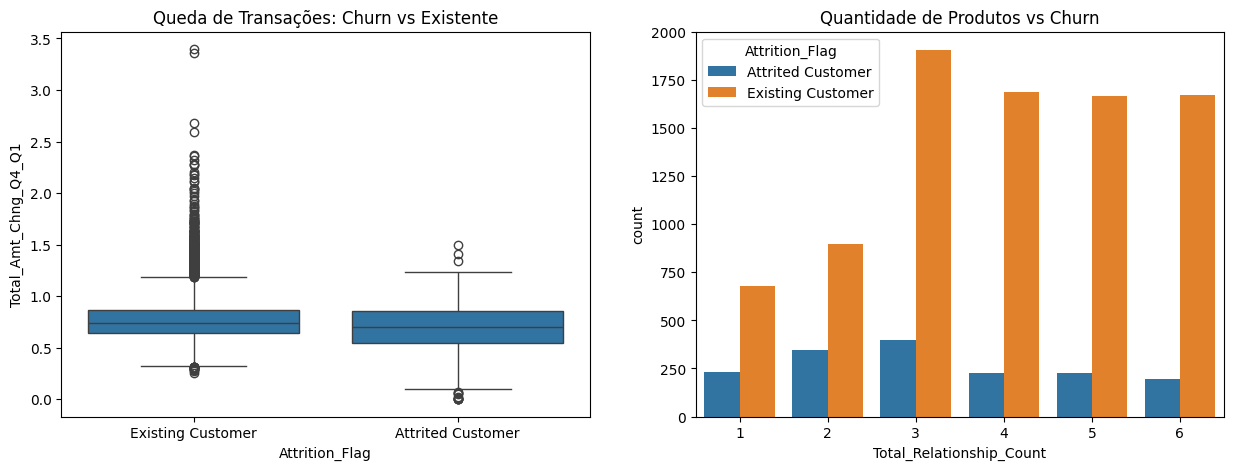

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Comparando a queda de transações e número de produtos
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Queda de transações (Q4 vs Q1)
sns.boxplot(x='Attrition_Flag', y='Total_Amt_Chng_Q4_Q1', data=df, ax=ax[0])
ax[0].set_title('Queda de Transações: Churn vs Existente')

# Plot 2: Quantidade de Produtos
sns.countplot(x='Total_Relationship_Count', hue='Attrition_Flag', data=df, ax=ax[1])
ax[1].set_title('Quantidade de Produtos vs Churn')

plt.show()

In [46]:
def calcular_alerta_senior(row):
    score = 0
    if row['Total_Amt_Chng_Q4_Q1'] < 0.6: score += 40  # Redução brusca
    if row['Months_Inactive_12_mon'] >= 2: score += 30 # Inatividade perigosa
    if row['Contacts_Count_12_mon'] > 3: score += 20   # Reclamações
    if row['Total_Relationship_Count'] <= 2: score += 10 # Pouco vínculo
    return score

df['Heuristic_Score'] = df.apply(calcular_alerta_senior, axis=1)

# Verificando a precisão da sua regra de negócio
print(df.groupby(df['Heuristic_Score'] >= 70)['churn'].mean())

Heuristic_Score
False    0.130932
True     0.325161
Name: churn, dtype: float64


In [48]:
# 1. Seleção de Features Relevantes
# Removemos CLIENTNUM e as colunas de "Naive Bayes" que costumam vir no fim desse dataset

# Calculate Avg_Utilization_Ratio first and add to df
df['Avg_Utilization_Ratio'] = df['Total_Revolving_Bal'] / df['Credit_Limit']

cols_to_keep = [
    'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
    'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
    'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]

df_clean = df[cols_to_keep].copy()

# 2. Encoding das Categóricas
# Attrition_Flag: Existing=0, Attrited=1
df_clean['Attrition_Flag'] = df_clean['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# Para as outras (Gender, Education, etc), usamos One-Hot Encoding
df_final = pd.get_dummies(df_clean, drop_first=True)

print(f"Novas colunas após Encoding: {df_final.shape[1]}")

Novas colunas após Encoding: 32


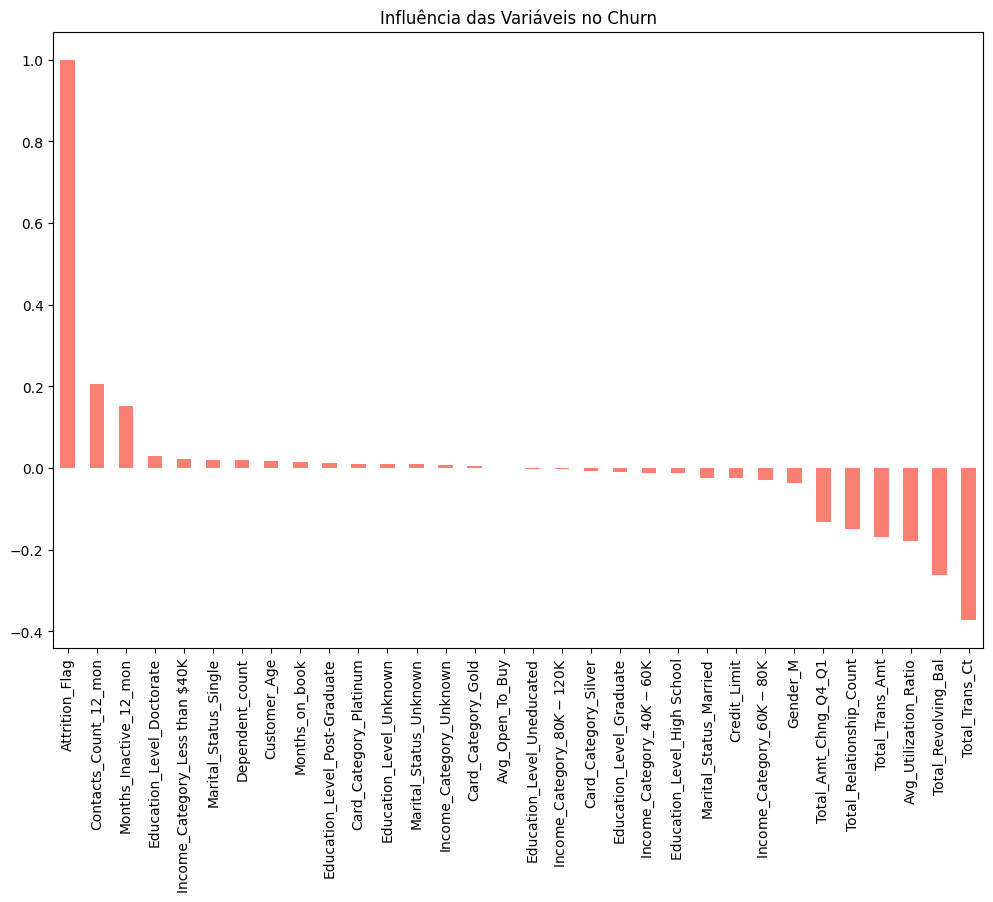

In [52]:
plt.figure(figsize=(12, 8))
# Olhando a correlação de todas as variáveis com o nosso alvo (Attrition_Flag)
correlacoes = df_final.corr()['Attrition_Flag'].sort_values(ascending=False)
correlacoes.plot(kind='bar', color='salmon')
plt.title("Influência das Variáveis no Churn")
plt.show()

#RandomForest

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Separando X e y
X = df_final.drop('Attrition_Flag', axis=1)
y = df_final['Attrition_Flag']

# Split Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Treinando o Modelo Sênior
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Gerando o Score de Risco (0-100) para o time de Marketing
X_test['Probabilidade_Churn'] = rf_model.predict_proba(X_test)[:, 1] * 100
X_test['Score_Risco'] = X_test['Probabilidade_Churn'].round(2)

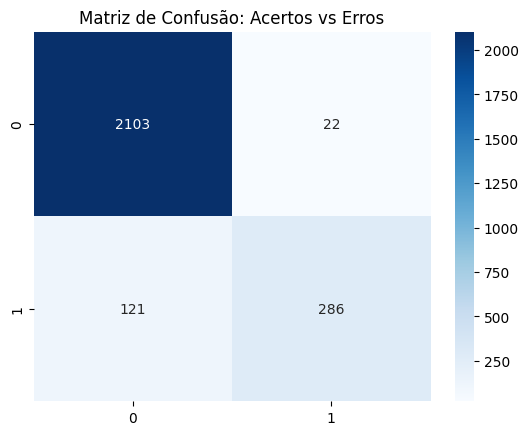

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2125
           1       0.93      0.70      0.80       407

    accuracy                           0.94      2532
   macro avg       0.94      0.85      0.88      2532
weighted avg       0.94      0.94      0.94      2532



In [56]:
from sklearn.metrics import confusion_matrix, classification_report

# Drop the 'Probabilidade_Churn' and 'Score_Risco' columns from X_test before prediction
X_test_for_prediction = X_test.drop(columns=['Probabilidade_Churn', 'Score_Risco'], errors='ignore')

# Matriz de Confusão para ver erros e acertos
sns.heatmap(confusion_matrix(y_test, rf_model.predict(X_test_for_prediction)), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão: Acertos vs Erros')
plt.show()

print(classification_report(y_test, rf_model.predict(X_test_for_prediction)))

#Threshold

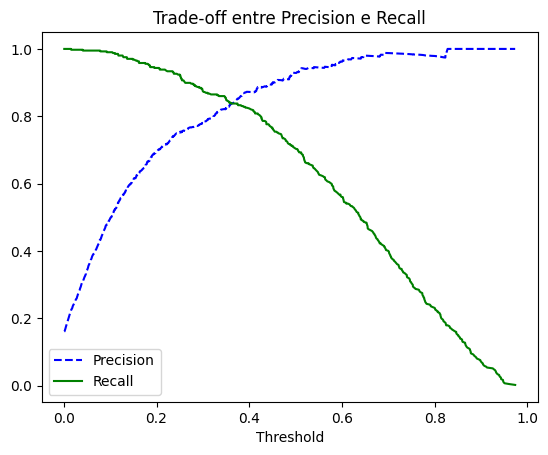

In [64]:
from sklearn.metrics import precision_recall_curve

# Pegando apenas as probabilidades da classe 1 (Churn)
y_scores = rf_model.predict_proba(X_test_for_prediction)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plotando a curva para análise
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.title('Trade-off entre Precision e Recall')
plt.legend()
plt.show()

Este é o gráfico mais importante para o seu Business Case. Note o ponto onde as linhas se cruzam (aproximadamente no threshold 0.35):

Cenário Agressivo (Threshold < 0.35): Se você baixar o threshold para 0.2, seu Recall sobe para quase 90% (você pega quase todo mundo que quer sair), mas sua Precision cai para uns 60%.

Uso: Ideal se a campanha de retenção for barata (ex: um push ou e-mail com dicas de bem-estar financeiro).

Cenário Conservador (Threshold > 0.35): Se você subir para 0.6, sua Precision vai para quase 100%, mas você perde metade das pessoas que iam sair (Recall despenca).

Uso: Ideal se você for dar um desconto agressivo ou isenção de anuidade, onde você só quer gastar com quem tem certeza absoluta que está saindo.

In [63]:
import numpy as np

thresholds = np.linspace(0.1, 0.9, 17)
resultados = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    resultados.append({
        'threshold': t,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'recall': tp/(tp+fn),
        'precision': tp/(tp+fp)
    })

pd.DataFrame(resultados)

,threshold,tp,fp,fn,tn,recall,precision
0,0.10,403,407,4,1718,0.990172,0.497531
1,0.15,394,250,13,1875,0.968059,0.611801
2,0.20,384,168,23,1957,0.943489,0.695652
3,0.25,375,124,32,2001,0.921376,0.751503
4,0.30,355,101,52,2024,0.872236,0.778509
5,0.35,346,74,61,2051,0.850123,0.823810
6,0.40,335,49,72,2076,0.823096,0.872396
7,0.45,311,35,96,2090,0.764128,0.898844
8,0.50,286,22,121,2103,0.702703,0.928571
9,0.55,255,15,152,2110,0.626536,0.944444


In [65]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

LTV = 148
C = 10
p = 0.30

thresholds = np.linspace(0.05, 0.95, 50)

resultados = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    lucro = tp * p * LTV - (tp + fp) * C

    resultados.append({
        'threshold': t,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'recall': tp/(tp+fn),
        'precision': tp/(tp+fp) if (tp+fp)>0 else 0,
        'clientes_impactadas': tp+fp,
        'lucro_esperado': lucro
    })

df_lucro = pd.DataFrame(resultados)

df_lucro.sort_values('lucro_esperado', ascending=False).head()

,threshold,tp,fp,fn,tn,recall,precision,clientes_impactadas,lucro_esperado
10,0.233673,380,135,27,1990,0.933661,0.737864,515,11722.0
9,0.215306,382,152,25,1973,0.938575,0.715356,534,11620.8
11,0.252041,373,122,34,2003,0.916462,0.753535,495,11611.2
8,0.196939,384,172,23,1953,0.943489,0.690647,556,11489.6
12,0.270408,366,111,41,2014,0.899263,0.767296,477,11480.4


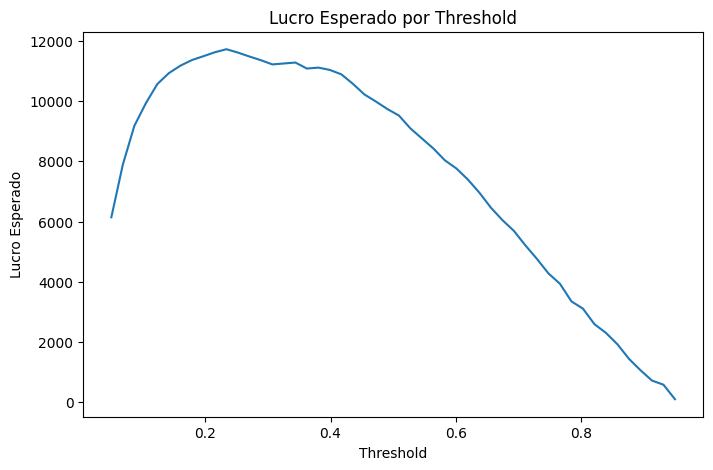

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_lucro['threshold'], df_lucro['lucro_esperado'])
plt.xlabel("Threshold")
plt.ylabel("Lucro Esperado")
plt.title("Lucro Esperado por Threshold")
plt.show()

#Conclusao

O modelo atinge AUC de 0.98 e permite capturar 93% das clientes que iriam churnar. Ao otimizar o threshold para lucro, identificamos que atuar em clientes com probabilidade ≥ 23% maximiza o retorno financeiro esperado. Neste cenário, impactamos 515 clientes e estimamos um lucro líquido de R$ 11.722 no período analisado.
###lista das pessoas para o marketing

In [67]:
# 1. Gerar as probabilidades para toda a base de teste
y_prob = rf_model.predict_proba(X_test_for_prediction)[:, 1]

# 2. Criar o DataFrame de resultados
lista_ouro = pd.DataFrame({
    'Probabilidade_Churn': y_prob,
    'Previsao_Modelo': (y_prob > 0.30).astype(int) # Aplicando o threshold de 30%
}, index=X_test_for_prediction.index)

# 3. Trazer de volta as variáveis originais para o Marketing entender o contexto
# (Substitua 'df_original' pelo nome do seu DataFrame antes do encoding)
lista_final = lista_ouro.join(df_clean.drop('Attrition_Flag', axis=1))

# 4. Filtrar apenas quem está acima do threshold (Alvos da Campanha)
alvos_marketing = lista_final[lista_final['Probabilidade_Churn'] > 0.30].sort_values(by='Probabilidade_Churn', ascending=False)

# 5. Exportar para CSV
alvos_marketing.to_csv('clientes_risco_churn.csv', index=True)

print(f"Lista gerada com {len(alvos_marketing)} clientes prioritárias.")

Lista gerada com 456 clientes prioritárias.
